<a target="_blank" href="https://colab.research.google.com/github/fintech-dl-hse/course/blob/main/seminars/11_eval_tts/11_eval_tts.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# Evaluation. VLLM. Test time scaling. PEFT.

---

## Perplexity

<img src="./static/perplexity.png" width=600 />

## LLM Eval

### Обзор бенчмарков для LLM

| Бенчмарк       | Область оценки              | Описание                                                                 | Примеры задач                             |
|----------------|-----------------------------|--------------------------------------------------------------------------|-------------------------------------------|
| **MMLU**       | Знания, мультидисциплинарность | Massive Multitask Language Understanding, проверяет знания по 57 предметам | История, медицина, математика и др.       |
| **HELLASWAG**  | Здравый смысл               | Проверка способности дополнять предложения логически                      | Завершение предложений                     |
| **ARC**        | Научные знания (K-12)       | AI2 Reasoning Challenge, тест школьного уровня                           | Научные вопросы с множественным выбором   |
| **GSM8K**      | Арифметика и рассуждение    | Grade School Math 8K — математические задачи для начальной школы        | Задачи на многошаговое рассуждение        |
| **TruthfulQA** | Правдоподобие vs. достоверность | Проверка способности избегать «убедительной, но ложной» информации       | Вопросы на правдивость                    |
| **WinoGrande** | Разрешение кореференций     | Проверка способности понимать, к кому относится местоимение              | Задачи в стиле Winograd Schema            |
| **OpenBookQA** | Комбинированные знания      | Требует знаний из «открытой книги» и способности их применять            | Применение фактов для вывода              |
| **HumanEval**  | Генерация кода              | Проверка способности LLM генерировать код, который проходит тесты        | Программные задачи с проверкой решений    |
| **MT-Bench**   | Диалоговые способности      | Multi-turn chat benchmark, фокус на диалогах и инструментах              | Рейтинги на основе GPT-4 / человеческих   |


### Likelihood vs Genrative Evaluation

| Подход             | Плюсы                                                                 | Минусы                                                                 |
|--------------------|------------------------------------------------------------------------|------------------------------------------------------------------------|
| **Likelihood-based** | - Объективная и воспроизводимая метрика<br>- Быстро<br>- Подходит для обучения и fine-tuning<br>- Хорош в zero-shot режиме | - Не отражает поведение генерации<br>- Чувствителен к формулировкам<br>- Может переоценивать запомненные ответы |
| **Decoding-based**   | - Ближе к реальному использованию<br>- Гибкая оценка: стиль, логика, креативность<br>- Учитывает reasoning и формат вывода | - Зависит от метода декодирования<br>- Требует human evaluation или сложных метрик<br>- Вычислительно дорогой<br>- Ошибки парсинга |


<img src="./static/likelihood_eval.png" width=800 />

<img src="./static/generative_eval.png" width=800 />

### Не всё так просто

- Бенчмарки утекают.
- Использовать людей для оценки LLM может быть дорого и долго (а иногда не надёжно) — LLM Arena.
- Можно использовать отдельную LLM для оценки новой модели. Но такая оценка может быть смещена.


### MMLU Example

```md
📘 Category: High School Biology

> Which of the following processes is part of cellular respiration?

A) Photosynthesis
B) Glycolysis
C) Transcription
D) DNA replication

✅ Correct Answer: B) Glycolysis
```

### [lm-evaluation-harness](https://github.com/EleutherAI/lm-evaluation-harness)

In [1]:
!git clone --depth 1 https://github.com/EleutherAI/lm-evaluation-harness
!cd lm-evaluation-harness && pip install -e .

Cloning into 'lm-evaluation-harness'...
remote: Enumerating objects: 16277, done.
remote: Counting objects: 100% (16277/16277), done.
remote: Compressing objects: 100% (6416/6416), done.
remote: Total 16277 (delta 9892), reused 15918 (delta 9831), pack-reused 0 (from 0)
Receiving objects: 100% (16277/16277), 4.54 MiB | 14.66 MiB/s, done.
Resolving deltas: 100% (9892/9892), done.
Obtaining file:///content/lm-evaluation-harness
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 4.1 MB/s eta 0:00:00
  B

In [5]:
!lm_eval --model hf \
    --model_args pretrained=Qwen/Qwen2.5-0.5B-Instruct \
    --tasks triviaqa \
    --device cuda:0 \
    --batch_size 128 \
    --limit 200

2026-05-18:15:57:52 WARNING  [config.evaluate_config:287] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-05-18:15:58:04 INFO     [_cli.run:388] Selected Tasks: ['triviaqa']
2026-05-18:15:58:04 WARNING  [evaluator:184] pretrained=Qwen/Qwen2.5-0.5B-Instruct appears to be an instruct or chat variant but chat template is not applied. Recommend setting
        `apply_chat_template` (optionally `fewshot_as_multiturn`).
2026-05-18:15:58:06 INFO     [evaluator:214] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-05-18:15:58:06 INFO     [evaluator:239] Initializing hf model, with arguments: {'pretrained': 'Qwen/Qwen2.5-0.5B-Instruct'}
2026-05-18:15:58:11 INFO     [models.huggingface:286] Using device 'cuda:0'
config.json: 100% 659/659 [00:00<00:00, 2.52MB/s]
tokenizer_config.json: 7.30kB [00:00, 18.5MB/s]
vocab.json: 2.78MB [00:00, 68.0MB/s]
merges.txt: 1.67MB [00

In [6]:
!lm_eval --model hf \
    --model_args pretrained=Qwen/Qwen2.5-0.5B-Instruct \
    --tasks triviaqa \
    --device cuda:0 \
    --batch_size 128 \
    --num_fewshot 5 \
    --limit 200

2026-05-18:16:00:07 WARNING  [config.evaluate_config:287] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-05-18:16:00:28 INFO     [_cli.run:388] Selected Tasks: ['triviaqa']
2026-05-18:16:00:28 WARNING  [evaluator:184] pretrained=Qwen/Qwen2.5-0.5B-Instruct appears to be an instruct or chat variant but chat template is not applied. Recommend setting
        `apply_chat_template` (optionally `fewshot_as_multiturn`).
2026-05-18:16:00:32 INFO     [evaluator:214] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-05-18:16:00:32 INFO     [evaluator:239] Initializing hf model, with arguments: {'pretrained': 'Qwen/Qwen2.5-0.5B-Instruct'}
2026-05-18:16:00:43 INFO     [models.huggingface:286] Using device 'cuda:0'
2026-05-18:16:00:45 INFO     [models.huggingface:579] Model parallel was set to False, max memory was not set, and device map was set to {'': 'cuda:0'}
Loadi

### Pitfalls eval-протоколов

Дополним краткий список из начала секции конкретикой — это то, что стоит уметь объяснять на собеседовании, а не повторять «там есть проблемы».

#### 1. Benchmark contamination (утечка)

В [Investigating Data Contamination in Modern Benchmarks for LLMs](https://arxiv.org/abs/2311.09783) показано, что для нескольких open-source LLM до 25% примеров MMLU/HellaSwag находятся в pretraining-корпусе по n-gram match. Llama-2 paper отдельно отчитывался по contamination для MMLU.

**Что делать:**
- проверять test-set membership через n-gram detection (есть готовые отчёты на HF Datasets);
- смотреть на свежие OOD-бенчмарки (GPQA, MMLU-Pro);
- больше доверять *закрытым* eval-сетам, в которые модель не могла слиться.

#### 2. Prompt format sensitivity

В [Sclar et al., 2023](https://arxiv.org/abs/2310.11324) показано: изменение разделителя в few-shot prompt (` `, `\n`, `\t`) даёт разброс точности на MMLU **до 76 процентных пунктов** для одной и той же модели. Это не «шум», это структурная проблема eval-протокола.

**Что делать:** репортить число с указанием конкретного template; сравнивать модели на *одинаковом* шаблоне; смотреть mean ± std по нескольким семантически эквивалентным шаблонам.

#### 3. LLM-as-judge bias

Из [Judging LLM-as-a-Judge, Zheng et al., 2023](https://arxiv.org/abs/2306.05685):

- **Position bias** — GPT-4 как судья предпочитает первый ответ в паре в 60%+ случаев при одинаковом качестве;
- **Verbosity bias** — судья предпочитает более длинные ответы при равном содержании;
- **Self-enhancement bias** — GPT-4 ставит чуть выше ответам из GPT-семейства.

**Что делать:** swap order и усреднять; ограничивать длину; не использовать тот же self-family как judge при прямом сравнении.

## vLLM-ускорение eval

Если мы хотим прогнать `triviaqa` на свежем чекпойнте — будет ли быстрее запустить **vLLM** и через **HTTP API** обращаться к нему, или взять `transformers.generate` напрямую? А если запустить vLLM **прямо в процессе** (без HTTP)?

Сравним три бекенда на одном и том же таске и чекпойнте:

| Бекенд | Команда | Что это |
|---|---|---|
| `hf` | `lm_eval --model hf ...` | `transformers.generate` напрямую, как в ячейках выше |
| `vllm` | `lm_eval --model vllm ...` | vLLM **в том же процессе**, через Python API |
| `local-completions` | `vllm serve ...` + `lm_eval --model local-completions ...` | vLLM как **HTTP-сервер**, lm-eval ходит по OpenAI-совместимому API |

In [15]:
%%time

# 1) HF (baseline) — transformers.generate напрямую
!lm_eval --model hf \
    --model_args pretrained=Qwen/Qwen2.5-0.5B-Instruct \
    --tasks triviaqa \
    --batch_size 16 \
    --limit 200

2026-05-18:16:11:42 WARNING  [config.evaluate_config:287] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-05-18:16:11:56 INFO     [_cli.run:388] Selected Tasks: ['triviaqa']
2026-05-18:16:11:56 WARNING  [evaluator:184] pretrained=Qwen/Qwen2.5-0.5B-Instruct appears to be an instruct or chat variant but chat template is not applied. Recommend setting
        `apply_chat_template` (optionally `fewshot_as_multiturn`).
2026-05-18:16:11:58 INFO     [evaluator:214] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-05-18:16:11:58 INFO     [evaluator:239] Initializing hf model, with arguments: {'pretrained': 'Qwen/Qwen2.5-0.5B-Instruct', 'dtype': 'bfloat16'}
2026-05-18:16:12:03 INFO     [models.huggingface:286] Using device 'cuda:0'
2026-05-18:16:12:04 INFO     [models.huggingface:579] Model parallel was set to False, max memory was not set, and device map was set to

In [17]:
%%time

# 2) vLLM в том же процессе — самый быстрый путь
# !pip install -q vllm

!lm_eval --model vllm \
    --model_args pretrained=Qwen/Qwen2.5-0.5B-Instruct,gpu_memory_utilization=0.85 \
    --tasks triviaqa \
    --batch_size auto \
    --limit 200

2026-05-18:16:19:58 WARNING  [config.evaluate_config:287] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-05-18:16:20:21 INFO     [_cli.run:388] Selected Tasks: ['triviaqa']
2026-05-18:16:20:21 WARNING  [evaluator:184] pretrained=Qwen/Qwen2.5-0.5B-Instruct appears to be an instruct or chat variant but chat template is not applied. Recommend setting
        `apply_chat_template` (optionally `fewshot_as_multiturn`).
2026-05-18:16:20:24 INFO     [evaluator:214] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-05-18:16:20:24 INFO     [evaluator:239] Initializing vllm model, with arguments: {'pretrained': 'Qwen/Qwen2.5-0.5B-Instruct', 'gpu_memory_utilization': 0.85}
INFO 05-18 16:20:51 [utils.py:240] non-default args: {'seed': 1234, 'gpu_memory_utilization': 0.85, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-0.5B-Instruct'}
INFO 05-18 16:20:52 [model.py:568

In [ ]:
%%time

# 3) vLLM как HTTP-сервер + lm-eval как HTTP-клиент

# В отдельном терминале / фоном:
# vllm serve Qwen/Qwen2.5-0.5B-Instruct --port 8000

!lm_eval --model local-completions \
    --model_args model=Qwen/Qwen2.5-0.5B-Instruct,base_url=http://localhost:8000/v1/completions,num_concurrent=16,tokenized_requests=False \
    --tasks triviaqa \
    --limit 200

#### ❓ **Вопрос**: мы взяли 0.5B модель и получили ×6–10 speedup от vLLM. Что произойдёт со speedup на 7B модели?

<details>

<summary><strong>Ответ</strong></summary>

Speedup *вырастет*. Continuous batching даёт тем больше выгоды, чем дороже один forward pass и чем больше разброс длин в батче — на больших моделях HF-батчинг с паддингом теряет ещё больше времени.</br>
Заявленные vLLM ×24 — это обычно 7–13B модели с длинной генерацией.</br>

</details>

---

## Test Time Scaling

### Chain Of Thoughts

**Chain of Thought (цепочка размышлений)** — это техника, при которой модель генерирует промежуточные шаги рассуждения перед тем, как дать финальный ответ. Она особенно полезна в задачах, требующих логического мышления или арифметических вычислений.

**Пример:**

**Вопрос:** Если у Маши 3 яблока, а у Пети в 2 раза больше, сколько всего яблок?

**Без CoT:** 6

**С CoT:** У Маши 3 яблока. У Пети в 2 раза больше: 3 * 2 = 6. Всего: 3 + 6 = 9.

Эта техника помогает:

- Увеличить точность в сложных задачах
- Сделать поведение модели более интерпретируемым

### Pass@k Sampling


<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/11_eval_tts/static/does_rl.png" width=600 />


[🤗 huggingface/trl GRPO Trainer](https://github.com/huggingface/trl/blob/main/trl/trainer/grpo_trainer.py)

In [ ]:
!pip install transformers

In [18]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# Qwen/Qwen2.5-0.5B
model_name = 'Qwen/Qwen2.5-0.5B-Instruct'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [19]:
num_generations = 64


MATH500_problem = """
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\\theta),$ where $r > 0$ and $0 \le \\theta < 2 \pi.$
"""

model_inputs = tokenizer( [ MATH500_problem ], return_tensors='pt' )
model_inputs = model_inputs.to(device)

input_ids = model_inputs['input_ids']
attention_mask = model_inputs['attention_mask']

input_ids.shape

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_6676/3967907362.py:5: SyntaxWarning: invalid escape sequence '\l'
  Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\\theta),$ where $r > 0$ and $0 \le \\theta < 2 \pi.$


torch.Size([1, 49])

In [20]:
input_ids = input_ids.repeat([num_generations, 1])
attention_mask = attention_mask.repeat([num_generations, 1])

input_ids.shape

torch.Size([64, 49])

In [21]:
model.generation_config

GenerationConfig {
  "bos_token_id": 151643,
  "do_sample": true,
  "eos_token_id": [
    151645,
    151643
  ],
  "pad_token_id": 151643,
  "repetition_penalty": 1.1,
  "temperature": 0.7,
  "top_k": 20,
  "top_p": 0.8
}

In [23]:
generation_config = {
    "do_sample": True,
    "temperature": 0.9,
    "top_p": 1.0,
    "top_k": None,
    "min_p": None,
    "repetition_penalty": 1.0,
}

output = model.generate(
    input_ids,
    attention_mask=attention_mask,
    **generation_config
)


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1590: UserWarning: Using the model-agnostic default `max_length` (=69) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


In [24]:
decoded_generations = tokenizer.batch_decode(output)
print("Total generations", len(decoded_generations))
print("Total unique generations", len(set(decoded_generations)))

Total generations 64
Total unique generations 21


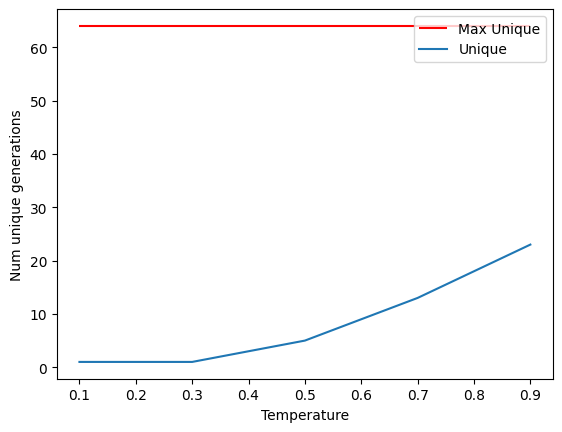

In [25]:
import matplotlib.pyplot as plt
import numpy as np

generation_config['do_sample'] = True

temperatures_range = np.arange(1, 10, 2) / 10
uniq_generations = []

for temperature in temperatures_range:
    generation_config['temperature'] = temperature
    output = model.generate(
        input_ids,
        attention_mask=attention_mask,
        **generation_config
    )
    decoded_generations = tokenizer.batch_decode(output)

    uniq_generations.append(len(set(decoded_generations)))

plt.ylabel("Num unique generations")
plt.xlabel("Temperature")
plt.hlines([ input_ids.shape[0] ], 0.1, 0.9, color='red', label='Max Unique')
plt.plot(temperatures_range, uniq_generations, label='Unique')
plt.legend()

### Temperature visualization

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlabel('Token Index', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Effect of Temperature (0-10) on Sampling Distribution', fontsize=14, pad=20)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# Original logits (model outputs before softmax)
logits = np.array([2.0, 1.5, 1.0, 0.5, 0.1])  # More varied distribution
token_labels = ['Token 1', 'Token 2', 'Token 3', 'Token 4', 'Token 5']

# Initialize bars with colors
colors = plt.cm.viridis(np.linspace(0, 1, len(logits)))
bars = ax.bar(token_labels, [0]*len(logits), color=colors)
texts = [ax.text(bar.get_x() + bar.get_width()/2, 0, '',
                ha='center', va='bottom', fontsize=10) for bar in bars]

# Temperature annotation with enhanced visibility
temp_text = ax.text(0.02, 0.95, 'Temperature: 0.00', transform=ax.transAxes,
                   ha='left', va='top', fontsize=14,
                   bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'))

# Add colorbar to show temperature scale
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=0, vmax=10))
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Temperature Scale', rotation=270, labelpad=15)

def apply_temperature(logits, temperature):
    """Apply temperature scaling to logits"""
    if temperature == 0:  # Handle zero temperature case
        temperature = 1e-10  # Very small value to avoid division by zero
    scaled_logits = logits / temperature
    return softmax(scaled_logits)

def update(frame):
    # Linear temperature range from 0 to 10
    temp = frame * 10 / 500  # frame goes from 0 to 100

    # Apply temperature
    probs = apply_temperature(logits, temp)

    # Update bars
    for bar, prob in zip(bars, probs):
        bar.set_height(prob)
        # Change color intensity based on temperature
        r, g, b, a = bar.get_facecolor()
        intensity = 0.5 + 0.5 * (temp / 10)  # Vary intensity with temperature
        bar.set_facecolor((r, g, b, intensity))

    # Update probability labels
    for text, bar in zip(texts, bars):
        text.set_text(f'{bar.get_height():.2f}')
        text.set_y(bar.get_height() + 0.02)
        text.set_color('black' if bar.get_height() < 0.7 else 'white')

    # Update temperature display
    temp_text.set_text(f'Temperature: {temp:.2f}')
    temp_text.set_color('red' if temp > 1 else 'blue')

    # Return all artists that need to be redrawn
    return list(bars) + texts + [temp_text]

# Create animation (100 frames for smooth transition)
ani = FuncAnimation(fig, update, frames=np.linspace(0, 100, 100),
                   blit=True, interval=200, repeat_delay=2000)

# For Jupyter notebook display
plt.close()
HTML(ani.to_html5_video())

# To save the animation (uncomment if needed)
# ani.save('temperature_effect_0_to_10.mp4', writer='ffmpeg',

### Count correct threads

In [27]:
generation_config = {
    "do_sample": True,
    "temperature": 0.9,
    "top_p": 1.0,
    "top_k": None,
    "min_p": None,
    "repetition_penalty": 1.0,
    "max_new_tokens": 500,
}

output = model.generate(
    input_ids,
    attention_mask=attention_mask,
    **generation_config
)

decoded_generations = tokenizer.batch_decode(output)

In [31]:
correct_answer = '3, \\frac{\\pi}{2}'

print("Count correct answers", sum( correct_answer in x for x in decoded_generations ))

Count correct answers 21


In [32]:
partially_correct = '\\frac{\\pi}{2}'

print("Count partially correct answers", sum( partially_correct in x for x in decoded_generations ))

Count partially correct answers 33


In [30]:
print(decoded_generations[1])


Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the rectangular coordinates \((0,3)\) to polar coordinates \((r, \theta)\), we need to find the values of \(r\) and \(\theta\).

1. **Calculate \(r\):**
   The formula for \(r\) in polar coordinates is:
   \[
   r = \sqrt{x^2 + y^2}
   \]
   Substituting \(x = 0\) and \(y = 3\):
   \[
   r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
   \]

2. **Calculate \(\theta\):**
   The formula for \(\theta\) in polar coordinates is:
   \[
   \theta = \tan^{-1}\left(\frac{y}{x}\right)
   \]
   Substituting \(x = 0\) and \(y = 3\):
   \[
   \theta = \tan^{-1}\left(\frac{3}{0}\right)
   \]
   Since the point \((0,3)\) lies on the positive \(y\)-axis, the angle \(\theta\) is:
   \[
   \theta = \frac{\pi}{2}
   \]

3. **Format the result:**
   The polar coordinates are already in the form \((r, \theta)\):
   \[
   (r, \theta) = \left(3, \fr

----

## Training Efficiency

### Mixed Precision

**Mixed precision** = forward/backward считаем в низкой точности (fp16/bf16), а master weights и накопление градиентов держим в fp32. На Tensor Core это даёт 2-3× ускорение матриц и почти вдвое меньше памяти под активации.

Для **fp16** нужен `GradScaler` — он динамически умножает loss на масштаб, чтобы маленькие градиенты не схлопывались в `0` (underflow). Для **bf16** scaler не нужен: диапазон экспонент тот же, что у fp32.

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2-0.5B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)

inputs = tokenizer("Mixed precision in PyTorch:", return_tensors="pt").to(device)
labels = inputs["input_ids"].clone()

# fp16 + GradScaler (классический AMP-паттерн)
scaler = torch.amp.GradScaler("cuda")
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

optimizer.zero_grad()
with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
    out = model(**inputs, labels=labels)

scaler.scale(out.loss).backward()   # масштабируем loss, чтобы градиенты не underflow
scaler.step(optimizer)              # unscale + step
scaler.update()                     # подстраиваем scale на следующий шаг

print(f"loss = {out.loss.item():.4f}")

### `dtype=torch.bfloat16`

**bf16** — формат с тем же диапазоном экспонент, что у fp32 (8 бит), но мантисса всего 7 бит. На Ampere/Hopper/TPU это нативный тип, и **`GradScaler` не нужен**: underflow практически не случается.

При загрузке через `from_pretrained(torch_dtype=torch.bfloat16)` веса сразу материализуются в bf16 (не проходят через fp32 → экономия памяти при загрузке). В современных архитектурах (Llama, Qwen, Mistral) внутри forward'а критичные операции сами **апкастятся в fp32** через `.float()` — например, `LlamaRMSNorm` считает variance в fp32 и возвращает результат обратно в bf16.

⚠️ **`model.to(torch.bfloat16)` — другое.** Этот вызов проходит по всем параметрам и **жёстко** переводит их в bf16 без оглядки на то, как реализован модуль. Если ваша модель/слой не апкастит критичные операции вручную — точность поплывёт. Поэтому в реальных тренировочных пайплайнах используют **mixed precision** (`torch.amp.autocast(dtype=bfloat16)` или `Trainer(bf16=True)`): веса хранятся в fp32, autocast сам решает, что считать в bf16, а что в fp32.

В fp32 принято держать (autocast делает это автоматически):

- **LayerNorm / RMSNorm / BatchNorm** — статистики `mean`/`var` и `1/sqrt(var + eps)` чувствительны к точности;
- **Softmax / log_softmax** (в attention и в loss) — нормировка через `sum(exp(x))` теряет младшие биты;
- **Cross-entropy loss** — `log` от очень маленьких вероятностей легко улетает в `-inf` в bf16;
- **Reduction-операции** над длинной осью — `sum`, `mean`, `cumsum`, `var` — ошибка округления накапливается;
- **Optimizer states** (Adam'овские `m`, `v` и master weights) — иначе `lr * grad` округлится в `0` и обновление весов остановится.

Матричные умножения (`linear`, `matmul`, `conv`, `bmm`) и поэлементные активации (`gelu`, `silu`, `relu`) — наоборот, прекрасно считаются в bf16 и дают весь speedup.

In [ ]:
import torch
from transformers import AutoModelForCausalLM

model_name = "Qwen/Qwen2-0.5B-Instruct"

# fp32 -> ~4 байта на параметр
model_fp32 = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float32)
size_fp32 = sum(p.numel() * p.element_size() for p in model_fp32.parameters())

# bf16 -> ~2 байта на параметр
model_bf16 = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16)
size_bf16 = sum(p.numel() * p.element_size() for p in model_bf16.parameters())

print(f"fp32: {size_fp32 / 1e9:.2f} GB")
print(f"bf16: {size_bf16 / 1e9:.2f} GB  ({size_fp32 / size_bf16:.1f}x меньше)")
print(f"param dtype: {next(model_bf16.parameters()).dtype}")

### Batch Size

Большой **effective batch size** улучшает utilization GPU и стабильность градиента, но память под активации растёт линейно по батчу. Когда модель в память помещается, а батч `B` — уже нет, используют **gradient accumulation**: делаем backward по микро-батчам размера `b`, копим градиенты `B / b` шагов и только тогда вызываем `optimizer.step()`.

Loss обязательно делим на число шагов накопления, иначе градиент будет в `B / b` раз больше ожидаемого.

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2-0.5B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

micro_batch_size = 2
accumulation_steps = 4   # эффективный батч = 2 * 4 = 8

prompts = ["Hello"] * micro_batch_size
batch = tokenizer(prompts, return_tensors="pt", padding=True).to(device)
labels = batch["input_ids"].clone()

optimizer.zero_grad()
for step in range(accumulation_steps):
    out = model(**batch, labels=labels)
    # делим loss, чтобы итоговый grad соответствовал среднему по большому батчу
    (out.loss / accumulation_steps).backward()

optimizer.step()         # один шаг оптимизатора на accumulation_steps backward'ов
optimizer.zero_grad()
print(f"effective batch size = {micro_batch_size * accumulation_steps}")

### Torch Compile

`torch.compile` (PyTorch 2.0+) трассирует граф вычислений, делает kernel fusion и подменяет реализации операторов на оптимизированные через TorchInductor (или другой бэкенд).

На **первом** forward происходит компиляция — он медленный. Дальнейшие forward'ы быстрее обычных в 1.3–2× на трансформерах. Если меняются формы тензоров, возможна перекомпиляция — используют `mode="reduce-overhead"` или `dynamic=True`.

In [ ]:
import time
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2-0.5B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)
inputs = tokenizer("torch.compile is", return_tensors="pt").to(device)

compiled_model = torch.compile(model)

# первый forward — компиляция, его в замер не включаем
_ = compiled_model(**inputs)
torch.cuda.synchronize() if device == "cuda" else None

# warm forward — уже на скомпилированном графе
start = time.perf_counter()
for _ in range(10):
    _ = compiled_model(**inputs)
torch.cuda.synchronize() if device == "cuda" else None
print(f"compiled: {(time.perf_counter() - start) / 10 * 1000:.2f} ms/forward")

### PEFT

**PEFT** (Parameter-Efficient Fine-Tuning) — обучаем не всю модель, а маленькую добавку, при этом базовые веса заморожены. Самый ходовой метод — **LoRA**: для целевых линейных слоёв обучаем низкоранговую поправку `ΔW = B @ A`, где `A ∈ R^{r×d}`, `B ∈ R^{d×r}`, `r` маленький (4–64).

В итоге обучаемых параметров — доли процента от модели, чекпойнт занимает десятки мегабайт, а forward почти не замедляется. Базовая модель не «забывает» предобучение.


#### LoRA - [paper](https://arxiv.org/pdf/2106.09685)
<img src="./static/lora.png" width=400 />

In [ ]:
# !pip install peft
import torch
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

model_name = "Qwen/Qwen2-0.5B-Instruct"
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16)

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,                                 # ранг низкоранговой поправки
    lora_alpha=16,                       # масштабирующий коэффициент
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"], # к каким матрицам attention применяем LoRA
)

peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()
# typical: trainable params: ~0.4M | all params: ~494M | trainable%: ~0.1%

#### ❓ **Вопрос**: Почему матрица B инициализируется нулями? Как быть с ассиметрией, с которой мы боролись на втором занятии, когда говорили, что нулями инициализировать плохо?

<details>

<summary><strong>Ответ</strong></summary>

Чтобы не сломать целевые веса. Вся ассиметрия ледит уже в матрице A.

</details>

### The asynchronous nature of CUDA

CUDA-кернелы запускаются **асинхронно**: `kernel.launch()` возвращает управление в Python ещё до того, как GPU реально посчитает. Поэтому наивный `time.time()` вокруг forward мерит время **постановки в очередь**, а не вычисления — и показывает фантастические 0.1 ms на forward'е, который на самом деле занимает 50 ms.

Корректно мерить либо через `torch.cuda.synchronize()` перед стартом и стопом, либо через `torch.cuda.Event(enable_timing=True)`. Любая операция, перетаскивающая данные на CPU (`.item()`, `.cpu()`, `print(tensor)`), тоже неявно синхронизируется.

In [ ]:
import time
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2-0.5B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)
inputs = tokenizer("CUDA is async", return_tensors="pt").to(device)

# warmup
for _ in range(3):
    _ = model(**inputs)
torch.cuda.synchronize()

# ❌ наивно: меряем только запуск кернелов
start = time.perf_counter()
for _ in range(10):
    out = model(**inputs)
naive_ms = (time.perf_counter() - start) / 10 * 1000

# ✅ правильно: синхронизируемся перед остановкой таймера
start = time.perf_counter()
for _ in range(10):
    out = model(**inputs)
torch.cuda.synchronize()
correct_ms = (time.perf_counter() - start) / 10 * 1000

# ✅ через CUDA events — рекомендуемый способ
start_evt = torch.cuda.Event(enable_timing=True)
end_evt = torch.cuda.Event(enable_timing=True)
start_evt.record()
for _ in range(10):
    out = model(**inputs)
end_evt.record()
torch.cuda.synchronize()
events_ms = start_evt.elapsed_time(end_evt) / 10

print(f"naive time.time (без sync):     {naive_ms:.2f} ms/forward  <- занижено")
print(f"time.time + cuda.synchronize:   {correct_ms:.2f} ms/forward")
print(f"cuda.Event.elapsed_time:        {events_ms:.2f} ms/forward")

## Inference Efficiency: vllm



#### ⚡️ KV-Cache

[➡️ Код ⬅️](https://github.com/huggingface/transformers/blob/aeac7140f5fe407ee9f23f30b0ed34752bae19cf/src/transformers/models/llama/modeling_llama.py#L267)


Во время инференса вычисления делят на 2 стадии:

1) Prefill - вычисление KV-Cache для длинного контекста. Это compute-bound задача.

2) Decode - генерация токенов один за одним. Это memory-bound задача. На вход получает только один эбэмддинг(!) и KV-Cache



<img src="./static/prefill.png" width=600 />

<img src="./static/decode.png" width=600 />

#### ❓ **Вопрос**: Нужен ли KV-Cache во время обучения (pretrain / sft)?

<details>

<summary><strong>Ответ</strong></summary>

Нет. Во время обучения pretrain, sft используется только prefill-стадия. Но для RL Alignment используется генерация - там еще как используется!

</details>

#### ❓ **Вопрос**: Возможен ли былы бы KV-Cache если бы у нас был Bidirectional Attention (как в bert)?

<details>

<summary><strong>Ответ</strong></summary>

Нет, каузальная маска - это то, благодаря чему возмжоен KV-Cache. Если бы будущие токены влияли бы на предыдущие,
было бы нельзя сохранять кэши для предыдущих токенов.
Сравнение с bert в тексте вопроса не очень правильное - bert не гереративная модель.

</details>

#### ❓ **Вопрос**: Сколько времени живет KV-Cache в клод коде?

<details>

<summary><strong>Ответ</strong></summary>

5 минут.

Это значит, что если между вашими промтами прошло больше 5 минут, ваш запрос будет стоить сильно дороже, потому что чтение кэшированых токенов в 10 раз дешевле, чем пересчет kv-cache.

</details>

#### ❓ **Вопрос**: Где хранится KV-Cache?

<details>

<summary><strong>Ответ</strong></summary>

Выгружается в оперативную память когда запрос заканчивает обработку. Поэтому она и подорожала в этом году. И еще KV-Cache весят довольно много - для 100k токенов для 8B модели 13GB.

</details>

#### ⚡️ PagedAttention — KV-cache как страницы памяти

**Проблема.** В наивной реализации под каждый запрос резервируется непрерывный кусок памяти под KV-cache **на максимальную длину** (например, 2048 токенов). Запросы заканчиваются раньше — слоты простаивают. Это **внутренняя и внешняя фрагментация**, та же боль, что в ОС с непрерывным выделением памяти.

**Решение.** KV-cache режется на **блоки по 16 токенов**. Каждый запрос получает не один кусок, а список блоков — как страницы в виртуальной памяти. Есть пул свободных блоков (`free_block_queue`) и таблица `request → blocks`. Память выделяется по мере роста, без избыточного резерва. Free space utilization доходит до ~96% против ~20–40% у наивной схемы (это та цифра, ради которой статью «vLLM: Easy, Fast, and Cheap LLM Serving with PagedAttention» вообще писали).

**Бонусная фича от страничной схемы:** одинаковые KV-страницы можно **шарить между запросами** (см. prefix caching ниже).


#### ⚡️ Continuous batching (iteration-level scheduling)

**Проблема.** В static batching батч из N запросов ждёт, пока **самый длинный** запрос не сгенерирует свой финальный токен. Остальные слоты после своего EOS «жуют padding» — GPU тратит FLOPs впустую. Падение throughput тем сильнее, чем больше разброс длин в батче.

**Решение.** Планирование на уровне **итерации** (один forward = одна итерация), а не на уровне батча. Все активные sequences «склеиваются в одну плоскую super-sequence», attention-маска изолирует их друг от друга. Как только запрос закончил — его слот сразу занимает новый из очереди. **Никаких padding-FLOPs.**


И кое-что еще:

- [Inside vLLM: Anatomy of a High-Throughput LLM Inference System](https://www.aleksagordic.com/blog/vllm)

---

## Дополнительные материалы

### Evaluation
- [Inside vLLM: Anatomy of a High-Throughput LLM Inference System](https://www.aleksagordic.com/blog/vllm)
- [Человек и LLM. Как оценивать качество моделей и строить метрики](https://habr.com/ru/companies/yandex/articles/861084/)


### Test Time Scaling

- [🤗 huggingface/trl](https://github.com/huggingface/trl) HF transformers reinforcement learning
- [GRPO Qwen0.5 Huggingface Example](https://huggingface.co/docs/trl/main/grpo_trainer) — наглядный пример работы GRPO на маленькой модельке и игрушечной задачке
- [The State of Reinforcement Learning for LLM Reasoning](https://magazine.sebastianraschka.com/p/the-state-of-llm-reasoning-model-training) (Sebastian Raschka, 2025) — свежий пост, но база
- [Mini-R1: Reproduce Deepseek R1 „aha moment" a RL tutorial](https://www.philschmid.de/mini-deepseek-r1) — нужно 4 H100 и за 6 часов вы воспроизвели «aha moment» на настоящем, не игрушечном бенчмарке по математическим навыкам модельки
- [Speculations on Test-Time Scaling | Richard M. Karp Distinguished Lecture](https://www.youtube.com/watch?v=6fJjojpwv1I) — Sasha Rush (Associate Professor @ Cornell University, Researcher @ HuggingFace 🤗) — сюда за интуицией
- [Scaling test time compute with open models](https://huggingface.co/spaces/HuggingFaceH4/blogpost-scaling-test-time-compute) — Блог HF. Пример test time scaling, очень интересный, но немножко тупиковый (см. последнюю часть — «Where to go from here?»). [**Разбор в Сиолошной**](https://t.me/seeallochnaya/2136)
- [DPO в GigaChat](https://habr.com/ru/companies/sberdevices/articles/890552/) — как заводили DPO в GigaChat (спойлер: завелся, но не просто)
- [PPO и DPO в YandexGPT](https://habr.com/ru/companies/yandex/articles/817391/) — как заводили PPO и DPO в YandexGPT
- [**DeepSeek-R1 для чайников**](https://habr.com/ru/companies/airi/articles/879178/) — разбор GRPO на Хабре от Антона Разжигаева

**Работает ли RL в LLM Alignment**

- [Reasoning models do not always say what they think](https://www.anthropic.com/research/reasoning-models-dont-say-think) — (anthropic, 2025) — [Статья](https://assets.anthropic.com/m/71876fabef0f0ed4/original/reasoning_models_paper.pdf), [**Разбор в «Гречневые мысли»**](https://t.me/buckwheat_thoughts/181). А что если все, что генерят ризонеры во время процесса мышления, — это просто побочный продукт? Может быть, на буст в качестве влияет большее количество сгенеренных токенов в контексте и интерпретация задачи на промежуточных слоях трансформера, но не то, что на самом деле генерируется при декодировании?
- [Does Reinforcement Learning Really Incentivize Reasoning Capacity in LLMs Beyond the Base Model?](https://www.arxiv.org/abs/2504.13837) [**Разбор AbstractDL**](https://t.me/abstractDL/332)



---

### ⚠️ ⚠️ ⚠️ На следующей неделе занятия не будет ⚠️ ⚠️ ⚠️